In [94]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn 
import pickle as pkl
import os
import networkx as nx

from tqdm import tqdm
from typing import Any
from pathlib import Path
from dotenv import load_dotenv

# Schedules

In [115]:
def linear_schedule(time: Any):
    return time

def sin2_schedule(time: Any):
    t = torch.as_tensor(time)
    return torch.sin(0.5 * np.pi * t) ** 2

def polynomial_schedule(time: Any, p: float = 2.0):
    t = torch.as_tensor(time)
    return t ** float(p)

def tanh_schedule(time: Any, a: float = 5.0):
    t = torch.as_tensor(time)
    return 0.5 * (1.0 + torch.tanh(a * (t - 0.5)))

# Hamiltonians

In [ ]:
def H_mixer(n: int,
            h: np.ndarray|None=None,
            ) -> qml.Hamiltonian:
    """
    n: number of qubits in the system.
    h: external field strength.
    """
    if h is None:
        h = np.ones(n)
    obs = [qml.PauliX(i) for i in range(n)]
    return qml.Hamiltonian(-h, obs)

def H_prob(n: int, 
           mu: float,
           h: np.ndarray|None=None,
           coupling: np.ndarray|None=None,
           ) -> qml.Hamiltonian:
    """
    n: number of qubits in the system.
    h: external field strength.
    coupling: couplings between qubits.
    """
    if h is None:
        h = np.ones(n)
    if coupling is None:
        coupling = np.ones((n, n))
    coupling = coupling.flatten()
    h_obs = [qml.PauliZ(i) for i in range(n)]
    h_hamiltonian = qml.Hamiltonian(-mu * h, h_obs)
    coupling_obs = []
    for i in range(n):
        for j in range(n):
            coupling_obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
    coupling_hamiltonian = qml.Hamiltonian(-coupling, coupling_obs)
    return h_hamiltonian + coupling_hamiltonian

def H_a(H_mixer: qml.Hamiltonian,
        H_prob: qml.Hamiltonian,
        schedule,
        ):
    def funct(time):
        lam = schedule(time)
        if isinstance(lam, torch.Tensor):
            lam = lam.detach().cpu().item()
        return (1 - lam) * H_mixer + lam * H_prob
    return funct

def A_lambda(l: int,
             H_mixer: qml.Hamiltonian,
             H_prob: qml.Hamiltonian,
             schedule: Any,
             time: torch.Tensor,
             ) -> list[qml.operation.Operator]:
    """ 
    Produces counter adiabatic terms.

    Important: if H_a and d_lambda_H_a are Hermitian, their commutator is
    anti-Hermitian. Multiplying by 1j makes it Hermitian again, which is what
    we need for unitary evolution via exp(-i * t * H).
    """
    # detaching to avoid conflicts of PennyLane wit torch
    lam = schedule(time)
    if isinstance(lam, torch.Tensor):
        lam = lam.detach().cpu().item()

    d_lambda_H_a_ = -H_mixer + H_prob
    H_a_ = (1 - lam) * H_mixer + lam * H_prob

    total_res: list[qml.operation.Operator] = []
    for k in range(1, l + 1):
        res = qml.commutator(H_a_, d_lambda_H_a_)
        for _ in range(2 * k - 2):
            res = qml.commutator(H_a_, res)
        total_res.append(qml.s_prod(1j, res))
    return total_res

# The circuit

In [69]:
def state(n: int, 
          l: int, 
          trotter_steps: int,
          H_mixer: qml.Hamiltonian,
          H_prob: qml.Hamiltonian,
          schedule: Any,
          cd_term: bool,
          q_device_name: str="default.qubit",
          ):
    
    # Quantum device
    qdev = qml.device(q_device_name, wires=n)

    # Precompute the counter-diabatic operator list (Hermitian terms)
    if cd_term:
        A_s = A_lambda(l, H_mixer, H_prob, schedule, time=1)
        alpha = nn.Parameter(torch.zeros(l), requires_grad=True) # startign with zeros and adding couteradiabati term, gradually
    else:
        alpha = None

    # Defining the parameters
    gamma = nn.Parameter(torch.rand(trotter_steps), requires_grad=True)
    beta = nn.Parameter(torch.rand(trotter_steps), requires_grad=True)

    @qml.qnode(qdev, interface="torch", diff_method="backprop")
    def circuit(gamma, beta, alpha, cd_term):

        # Starting from equal superposition
        for i in range(n):
            qml.Hadamard(i)

        # Parametrized quantum simulation algorithm (the bridge between annealing and digitalized circuit)
        for p in range(trotter_steps):
            qml.evolve(H_prob, coeff=gamma[p])
            qml.evolve(H_mixer, coeff=beta[p]) # Equivalent to evolving each qubit separately
            
            # Evolution by the couteradibatic term
            if cd_term:
                for l, res in enumerate(A_s):
                    qml.evolve(res, coeff=alpha[l])
        
        return qml.expval(H_prob) # expected value on the problem Hamiltonian
    
    return circuit, gamma, beta, alpha

# Optimization

In [191]:
def optimize(n: int, 
             trotter_steps: int, 
             H_mixer: qml.Hamiltonian, 
             H_prob: qml.Hamiltonian, 
             save_dir: str,
             cd_term: bool=True,
             num_iter: int=100,
             lr: float=0.001, 
             ):
    """
    Optimization.
    num_iter: number of iterations made by an optimizer.
    save_dir: saving directory.
    plot: if plot.
    """
    circuit, gamma, beta, alpha = state(n, l=1, trotter_steps=trotter_steps, 
                                 H_mixer=H_mixer, H_prob=H_prob, schedule=sin2_schedule, cd_term=cd_term)
    if alpha is None:
        optimizer = torch.optim.Adam([gamma, beta], lr=lr)
    else:
        optimizer = torch.optim.Adam([gamma, beta, alpha], lr=lr)
    losses = []

    # GD
    for _ in tqdm(range(num_iter)):
        optimizer.zero_grad()
        loss = circuit(gamma, beta, alpha, cd_term) 
        loss = torch.real(loss) # Making them real. Just to make it clear for autograd, sicne expected value of a hermitian oprator should be real.
        loss.backward()
        optimizer.step()
        losses.append(loss.detach().item())
    
    # Saves
    with open(f"{save_dir}/losses/losses.pkl", "wb") as file:
        pkl.dump(losses, file)

    torch.save(gamma, f"{save_dir}/parameters/gamma.pth")
    torch.save(beta, f"{save_dir}/parameters/beta.pth")
    torch.save(alpha, f"{save_dir}/parameters/alpha.pth")

## Optimization of the test problem

In [223]:
N = 4
H_mixer_ = H_mixer(N)
H_prob_ = H_prob(N, 1)

optimize(N, trotter_steps=3, H_mixer=H_mixer_, H_prob=H_prob_, save_dir="test_cd", cd_term=True)
optimize(N, trotter_steps=3, H_mixer=H_mixer_, H_prob=H_prob_, save_dir="test_no_cd", cd_term=False)

100%|██████████| 100/100 [00:01<00:00, 65.25it/s]


In [224]:
def training_plots(dir: str,
          save: bool=True,
          ):
    """
    For plotting.
    """
    with open(f"{dir}_cd/losses/losses.pkl", "rb") as file:
        losses_cd = pkl.load(file)

    with open(f"{dir}_no_cd/losses/losses.pkl", "rb") as file:
        losses_no_cd = pkl.load(file)

    plt.plot(range(len(losses_cd)), losses_cd, label="CD")
    plt.plot(range(len(losses_no_cd)), losses_no_cd, label="No CD")
    plt.legend()
    plt.grid()
    plt.ylabel(r"Expected value of $H_{\mathrm{Prob}}$")
    plt.xlabel("Epoch")
    if save:
        plt.savefig(f"plots/{dir}.png")
    plt.show()

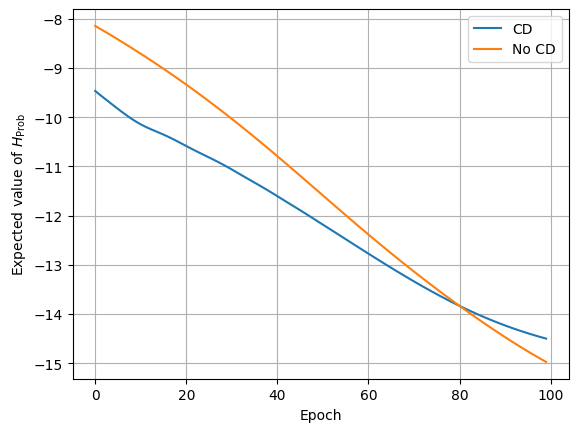

In [225]:
training_plots(dir="test")

## Optimization of a small real world  problem
Let us consider a small TSP problem.

In [226]:
def generate_random_tsp_qubo(n=9, penalty=10.0, seed=None):
    if seed is not None:
        np.random.seed(seed)

    D = np.random.rand(n, n)
    D = (D + D.T) / 2
    np.fill_diagonal(D, 0)

    N = n * n  
    Q = np.zeros((N, N))

    def idx(city, position):
        return city * n + position
    
    for i in range(n):
        for j in range(n):
            if i != j:
                for t in range(n):
                    t_next = (t + 1) % n
                    Q[idx(i, t), idx(j, t_next)] += D[i, j]

    for i in range(n):
        for t1 in range(n):
            Q[idx(i, t1), idx(i, t1)] -= penalty
            for t2 in range(n):
                if t1 != t2:
                    Q[idx(i, t1), idx(i, t2)] += penalty

    for t in range(n):
        for i1 in range(n):
            Q[idx(i1, t), idx(i1, t)] -= penalty
            for i2 in range(n):
                if i1 != i2:
                    Q[idx(i1, t), idx(i2, t)] += penalty

    return Q, D

In [227]:
number_of_cities = 2
Q, D = generate_random_tsp_qubo(n=number_of_cities, penalty=20, seed=42)
N = Q.shape[0]
H_mixer_ = H_mixer(N)
H_prob_ = H_prob(N, mu=1, coupling=Q)

(<Figure size 600x450 with 1 Axes>,
 <Axes: title={'center': 'TSP distance graph'}>)

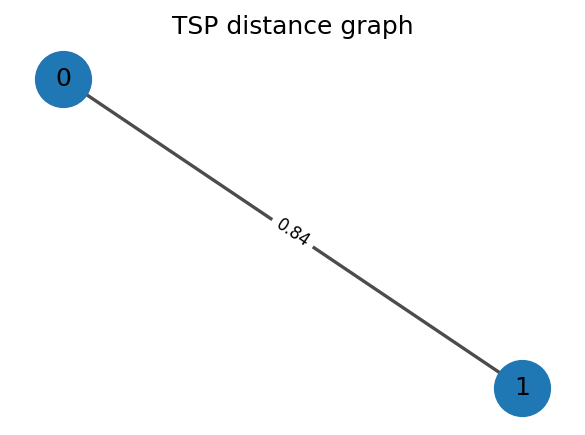

In [228]:
def plot_tsp_graph(
    D: np.ndarray,
    *,
    layout: str = "spring",
    seed: int = 0,
    show_edge_labels: bool = True,
    ax=None,
    title: str = "TSP distance graph",
    ):
    """Visualize a symmetric TSP distance matrix D as a weighted complete graph."""
    D = np.asarray(D, dtype=float)
    if D.ndim != 2 or D.shape[0] != D.shape[1]:
        raise ValueError(f"D must be a square matrix, got shape={D.shape}")

    n = D.shape[0]
    G = nx.complete_graph(n)
    for u, v in G.edges():
        G[u][v]["weight"] = float(D[u, v])

    if layout == "circular":
        pos = nx.circular_layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed, weight="weight")

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
    else:
        fig = ax.figure

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=700)
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.6, alpha=0.7)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={i: str(i) for i in range(n)})

    if show_edge_labels and n <= 12:
        edge_labels = {(u, v): f"{data['weight']:.2f}" for u, v, data in G.edges(data=True)}
        nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels, font_size=8)

    ax.set_title(title)
    ax.axis("off")
    fig.tight_layout()
    return fig, ax

plot_tsp_graph(D)

In [230]:
optimize(N, trotter_steps=3, H_mixer=H_mixer_, H_prob=H_prob_, save_dir="tsp9_cd", cd_term=True)
optimize(N, trotter_steps=3, H_mixer=H_mixer_, H_prob=H_prob_, save_dir="tsp9_no_cd", cd_term=False)

100%|██████████| 100/100 [00:01<00:00, 59.46it/s]


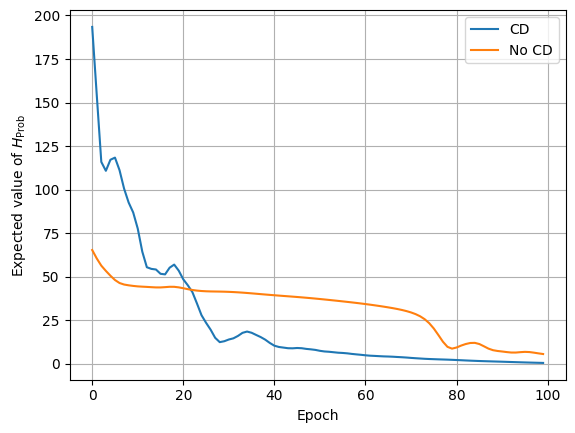

In [231]:
training_plots(dir="tsp9")

In [232]:
circuit_cd, _, _, _= state(N, l=1, trotter_steps=3, 
                                 H_mixer=H_mixer_, H_prob=H_prob_, schedule=linear_schedule, cd_term=True)
circuit_no_cd, _, _, _= state(N, l=1, trotter_steps=3, 
                                 H_mixer=H_mixer_, H_prob=H_prob_, schedule=linear_schedule, cd_term=False)

# Running the circuit alone

In [233]:
def run_circuit(
    circuit: Any,
    shots: int,
    q_dev,
    dir_: str,
    cd_term: bool,
    ):

    dir_path = Path(dir_)
    params_dir = dir_path / "parameters"

    gamma_t = torch.load(params_dir / "gamma.pth", map_location="cpu")
    beta_t = torch.load(params_dir / "beta.pth", map_location="cpu")
    alpha_t = torch.load(params_dir / "alpha.pth", map_location="cpu")

    def _to_numpy(x):
        if x is None:
            return None
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    gamma = _to_numpy(gamma_t)
    beta = _to_numpy(beta_t)
    alpha = _to_numpy(alpha_t)

    circ = qml.QNode(circuit.func, q_dev, interface="numpy")

    results_list = [circ(gamma, beta, alpha, cd_term) for _ in range(shots)]
    results = np.asarray(results_list)

    out_path = dir_path / "experiments" / "experiments.pkl"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with out_path.open("wb") as file:
        pkl.dump(results, file)


In [234]:
q_dev=qml.device("default.qubit", wires=4)
run_circuit(circuit_cd, shots=100, q_dev=q_dev, dir_="tsp9_cd/", cd_term=True)
run_circuit(circuit_no_cd, shots=100, q_dev=q_dev, dir_="tsp9_no_cd/", cd_term=False)

In [235]:
def plot_results(save_dir: str, save: bool = True, out_dir: str = "plots", show: bool = True):

    cd_path = Path(f"{save_dir}_cd") / "experiments" / "experiments.pkl"
    no_cd_path = Path(f"{save_dir}_no_cd") / "experiments" / "experiments.pkl"

    with cd_path.open("rb") as f:
        exp_cd = pkl.load(f)

    with no_cd_path.open("rb") as f:
        exp_no_cd = pkl.load(f)

    def _to_1d(a):
        a = np.asarray(a, dtype=float).squeeze()
        return a.reshape(-1)

    exp_cd = _to_1d(exp_cd)
    exp_no_cd = _to_1d(exp_no_cd)

    # Drop NaNs/infs if any
    exp_cd = exp_cd[np.isfinite(exp_cd)]
    exp_no_cd = exp_no_cd[np.isfinite(exp_no_cd)]

    fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=160)

    data = [exp_no_cd, exp_cd]
    labels = ["No CD", "CD"]

    bp = ax.boxplot(
        data,
        labels=labels,
        widths=0.55,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        whis=(5, 95),  # more robust whiskers than min/max
    )

    colors = ["#9aa0a6", "#4c78a8"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)
        patch.set_edgecolor(c)
        patch.set_linewidth(1.8)

    for med in bp["medians"]:
        med.set_color("#111111")
        med.set_linewidth(2.0)

    for mean in bp["means"]:
        mean.set_color("#111111")
        mean.set_linewidth(2.0)
        mean.set_linestyle("-")

    for whisk in bp["whiskers"]:
        whisk.set_color("#444444")
        whisk.set_linewidth(1.4)

    for cap in bp["caps"]:
        cap.set_color("#444444")
        cap.set_linewidth(1.4)

    # Add jittered individual points (nice distribution view)
    rng = np.random.default_rng(0)
    for i, y in enumerate(data, start=1):
        x = rng.normal(loc=i, scale=0.06, size=len(y))
        ax.scatter(x, y, s=14, alpha=0.35, color="#222222", linewidths=0)

    ax.set_title(f"{save_dir}: experiment results")
    ax.set_ylabel(r"Expected value of $H_{\mathrm{Prob}}$")
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    if save:
        out = Path(out_dir)
        out.mkdir(parents=True, exist_ok=True)
        fig.savefig(out / f"{save_dir}_experiments_boxplot.png", bbox_inches="tight")

    if show:
        plt.show()

    return fig, ax

/tmp/ipykernel_14425/521900755.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


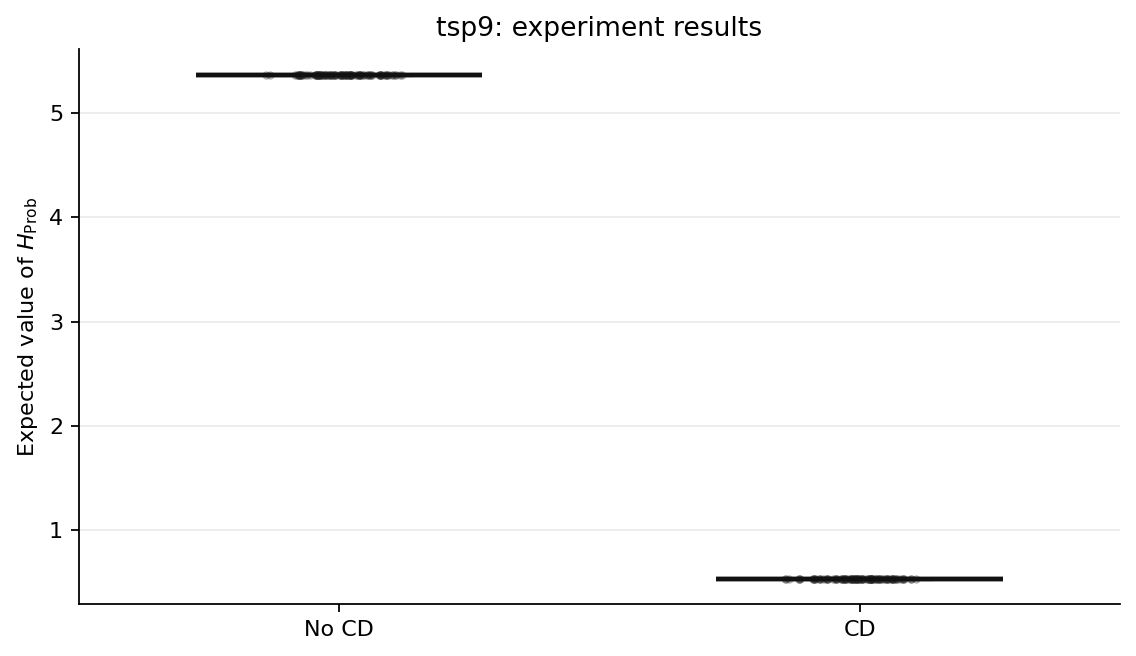

(<Figure size 1152x672 with 1 Axes>,
 <Axes: title={'center': 'tsp9: experiment results'}, ylabel='Expected value of $H_{\\mathrm{Prob}}$'>)

In [236]:
plot_results(save_dir="tsp9")

# Deploying on quantum machine

In [190]:
shots = 128
load_dotenv()
IBMQ_TOKEN = os.getenv("IBMQ_TOKEN")

q_dev = qml.device(
    "qiskit.remote",
    wires=N,
    backend="ibmq_boston",  
    ibmqx_token=IBMQ_TOKEN,
    shots=shots,
)

run_circuit(circuit_no_cd, shots=shots, q_dev=q_dev, dir_="tsp9_q_no_cd/", cd_term=False)
run_circuit(circuit_cd, shots=shots, q_dev=q_dev, dir_="tsp9_q_cd/", cd_term=True)

/home/filip/studia/master/pennylane-study/venv/lib/python3.13/site-packages/pennylane/devices/device_api.py:201: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


AttributeError: 'str' object has no attribute 'num_qubits'